## Masters Historical Round Performance


In [2]:
import pandas as pd
import numpy as numpy
import seaborn as sns
import matplotlib.pyplot as plt

Bring in Historical Performance Data (Scraped from https://www.masters.com/en_US/tournament/past_winners.html)

In [3]:
masters_df = pd.read_csv("C:/Personal Projects/finalized_masters_participants.csv")

masters_df.head()

,Year,Pos,Name,R1,R2,R3,R4,Total Score,Total Par,Made_Cut
0,2025,1,R McIlroy,72.0,66.0,66.0,73.0,277.0,-11.0,1
1,2025,2,J Rose,65.0,71.0,75.0,66.0,277.0,-11.0,1
2,2025,3,P Reed,71.0,70.0,69.0,69.0,279.0,-9.0,1
3,2025,4,S Scheffler,68.0,71.0,72.0,69.0,280.0,-8.0,1
4,2025,5,S Im,71.0,70.0,71.0,69.0,281.0,-7.0,1


In [18]:
##Convert Pos to the correct values right now it's the position but inside of brackets  lik "1" and we really want just a numerical feature

masters_df["Pos"] = masters_df["Pos"].str.extract(r"(\d+)")

masters_df["Pos"].head()

0    1
1    2
2    3
3    4
4    5
Name: Pos, dtype: object

Let's just take a general look a total score distributions over the 91 years of tournament history.

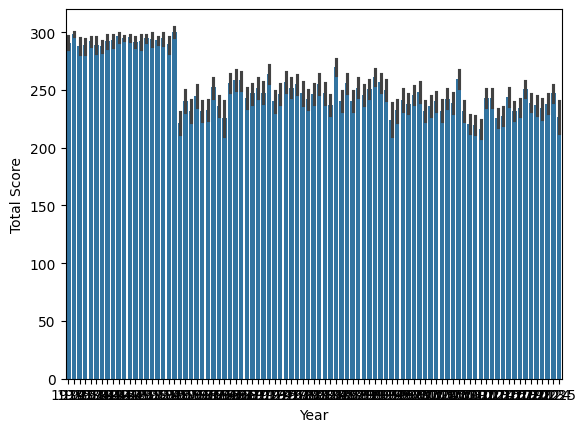

In [4]:
final_scores_plot = sns.barplot(data=masters_df, x= 'Year', y= 'Total Score')

That's a little hard to look at so lets bin the years into decades

In [5]:
masters_by_decade = masters_df.copy()

masters_by_decade["Decade"] = (masters_by_decade["Year"] // 10) * 10

masters_by_decade.head()

,Year,Pos,Name,R1,R2,R3,R4,Total Score,Total Par,Made_Cut,Decade
0,2025,1,R McIlroy,72.0,66.0,66.0,73.0,277.0,-11.0,1,2020
1,2025,2,J Rose,65.0,71.0,75.0,66.0,277.0,-11.0,1,2020
2,2025,3,P Reed,71.0,70.0,69.0,69.0,279.0,-9.0,1,2020
3,2025,4,S Scheffler,68.0,71.0,72.0,69.0,280.0,-8.0,1,2020
4,2025,5,S Im,71.0,70.0,71.0,69.0,281.0,-7.0,1,2020


In [6]:
decade_total_score = (masters_by_decade.groupby("Decade")["Total Score"].mean().reset_index())


decade_total_score["Decade"] = decade_total_score["Decade"].astype(str) + "s"

decade_total_score.head()

,Decade,Total Score
0,1930s,291.819430
1,1940s,293.074707
2,1950s,274.429373
3,1960s,245.005650
4,1970s,251.006376


Text(0, 0.5, 'Average Total Score')

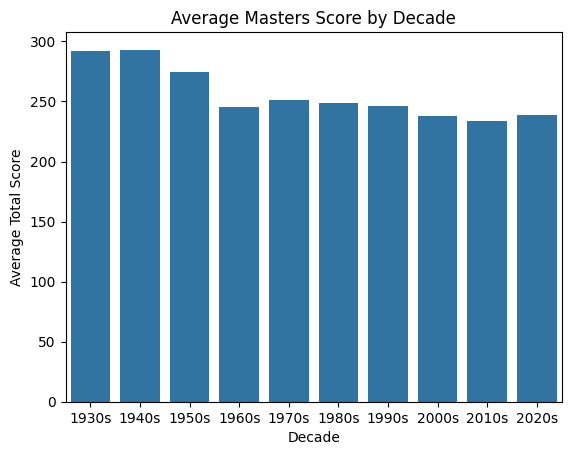

In [7]:
final_scores_plot_decades = sns.barplot(data=decade_total_score, x= 'Decade', y= 'Total Score')


plt.title("Average Masters Score by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Total Score")

Let's take a look at the round by round average scores (by decade)

In [8]:
decade_round_score = (masters_by_decade.groupby("Decade")[["R1", "R2", "R3", "R4"]].mean().reset_index())


decade_round_score["Decade"] = decade_round_score["Decade"].astype(str) + "s"

decade_round_score.head()

,Decade,R1,R2,R3,R4
0,1930s,75.583949,74.665602,75.066007,75.505119
1,1940s,74.647165,74.485014,74.704110,74.673295
2,1950s,75.664172,75.340649,75.395973,75.608919
3,1960s,74.718721,74.345585,73.654855,73.811416
4,1970s,74.030897,73.480416,73.187629,72.958763


Visualizing Average Round Scores by Decade

Text(0, 0.5, 'Average Score')

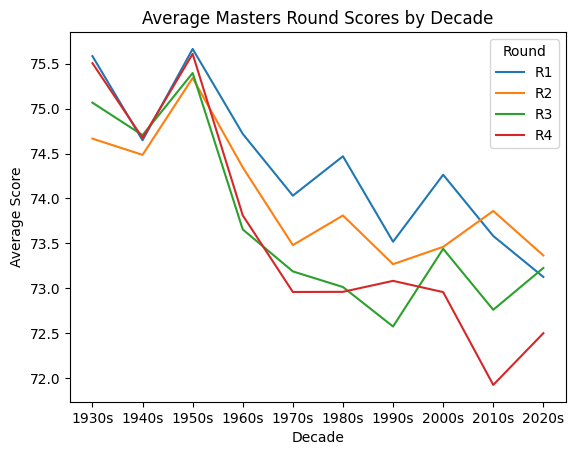

In [10]:
decade_round_long = decade_round_score.melt(
    id_vars="Decade",
    value_vars=["R1", "R2", "R3", "R4"],
    var_name="Round",
    value_name="Score")

decade_round_scores_plot = sns.lineplot(
    data=decade_round_long,
    x="Decade",
    y="Score",
    hue="Round")

plt.title("Average Masters Round Scores by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Score")



Looking at what the average scores are in terms of Total Par values over time

Text(0, 0.5, 'Average Total Par')

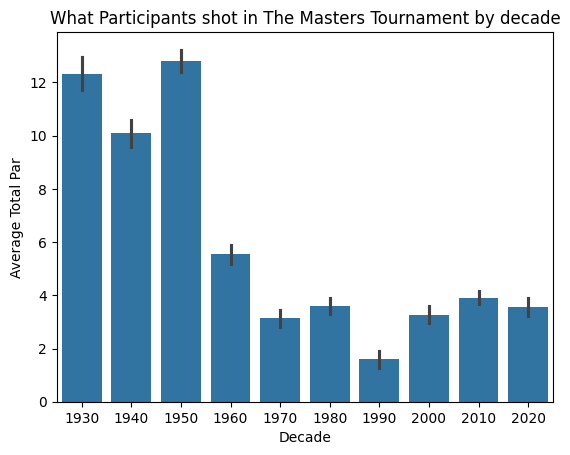

In [13]:
total_par_plot_decades = sns.barplot(data=masters_by_decade, x= 'Decade', y= 'Total Par')


plt.title("What Participants shot in The Masters Tournament by decade")
plt.xlabel("Decade")
plt.ylabel("Average Total Par")

How did Champions perform on total score basis?

In [21]:

champions_df = masters_df[masters_by_decade["Pos"] == "1"].copy()

champions_df.head()



,Year,Pos,Name,R1,R2,R3,R4,Total Score,Total Par,Made_Cut
0,2025,1,R McIlroy,72.0,66.0,66.0,73.0,277.0,-11.0,1
95,2024,1,S Scheffler,66.0,72.0,71.0,68.0,277.0,-11.0,1
184,2024,1,S Scheffler,66.0,72.0,71.0,68.0,277.0,-11.0,1
273,2024,1,S Scheffler,66.0,72.0,71.0,68.0,277.0,-11.0,1
362,2023,1,J Rahm,65.0,69.0,73.0,69.0,276.0,-12.0,1


In [23]:
champions_df["Decade"] = (champions_df["Year"] // 10) * 10

decade_winners_total_score = (champions_df.groupby("Decade")["Total Score"].mean().reset_index())


decade_winners_total_score["Decade"] = decade_winners_total_score["Decade"].astype(str) + "s"

decade_winners_total_score.head()

,Decade,Total Score
0,1930s,283.000000
1,1940s,280.571429
2,1950s,283.100000
3,1960s,280.750000
4,1970s,278.500000


Visualizing Masters Winner's Total Scores by Decade

Text(0, 0.5, 'Average Total Score')

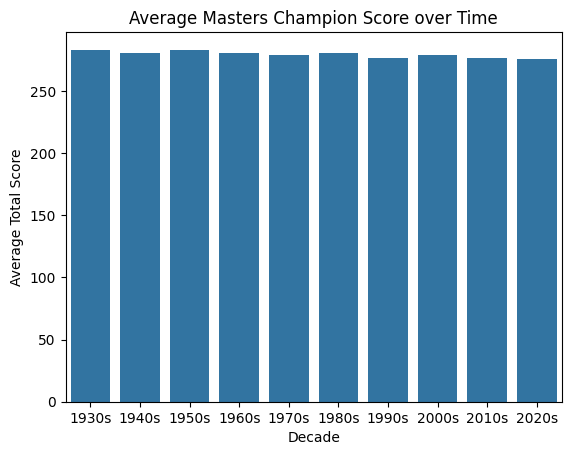

In [24]:
final_scores__winners_plot_decades = sns.barplot(data=decade_winners_total_score, x= 'Decade', y= 'Total Score')


plt.title("Average Masters Champion Score over Time")
plt.xlabel("Decade")
plt.ylabel("Average Total Score")

Looking at Round Scores for Masters Champions

In [25]:
decade_round_score_winners = (champions_df.groupby("Decade")[["R1", "R2", "R3", "R4"]].mean().reset_index())


decade_round_score_winners["Decade"] = decade_round_score_winners["Decade"].astype(str) + "s"

decade_round_score_winners.head()

,Decade,R1,R2,R3,R4
0,1930s,70.166667,71.000000,71.333333,70.500000
1,1940s,68.857143,70.571429,70.000000,71.142857
2,1950s,71.300000,70.900000,71.300000,69.600000
3,1960s,69.571429,69.821429,70.535714,70.821429
4,1970s,69.000000,70.100000,70.200000,69.200000


Text(0, 0.5, 'Average Score')

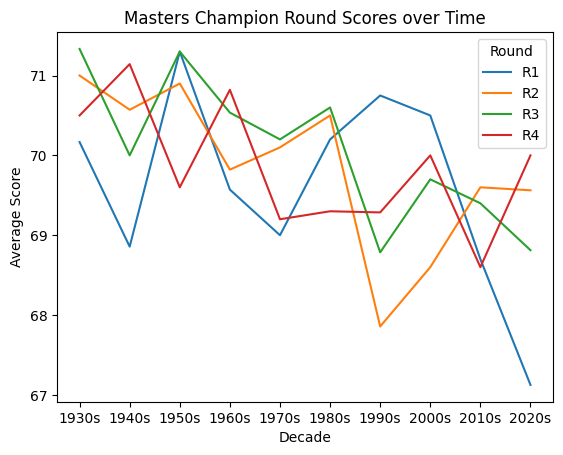

In [27]:
decade_round_long_winners = decade_round_score_winners.melt(
    id_vars="Decade",
    value_vars=["R1", "R2", "R3", "R4"],
    var_name="Round",
    value_name="Score")

decade_round_scores_winners_plot = sns.lineplot(
    data=decade_round_long_winners,
    x="Decade",
    y="Score",
    hue="Round")

plt.title("Masters Champion Round Scores over Time")
plt.xlabel("Decade")
plt.ylabel("Average Score")

Visualizing This